In [1]:
from utils import * 
import subprocess
import json 
from scipy.spatial.distance import pdist
import toytree

%load_ext autoreload 
%autoreload 2

In [2]:
# TODO
# (1) Ask Jack about how best to assess multimer state (i.e. something better than iPTM)?
# (2) Compute interface PAE. 
# (3) Look into PAE around the pore area. 
# (4) Re-run multimer predictions with more seeds

In [3]:
# ncbi_blast_df = BLASTFile.from_file('../data/genes/blast/cluster_3-clustered_nr.json').to_df()
# ncbi_blast_df.title.value_counts().index.tolist()

In [10]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[(genes_df.cluster_id == 3) & (genes_df.genome_id != 'bz_12')].copy()

FASTAFile.from_df(genes_df).write('../data/genes/cluster_3.faa')
# subprocess.run('muscle -align ../data/genes/cluster_3.faa -output ../data/genes/cluster_3.afa', shell=True, check=True)

ATPASE_DOMAIN_COORDS = (24, 215) # Relative to the Betazoid cluster_3 MSA.
msa = MSA.from_file(path='../data/genes/cluster_3.afa')

# Use the MSA to determine the ATPase domain coordinates for each sequence, even those lacking an annotation. 
for gene_id in genes_df.index:
    genes_df.loc[gene_id, 'atpase_domain_start'] = msa.map_idx_from_msa(ATPASE_DOMAIN_COORDS[0], gene_id)
    genes_df.loc[gene_id, 'atpase_domain_stop'] = msa.map_idx_from_msa(ATPASE_DOMAIN_COORDS[1], gene_id)

In [ ]:
date = '07_25_2026'
# The ColabFold-generated MSAs are already pretty good, so probably wouldn't gain much from doing custom ones here. 

with open(f'../data/genes/colabfold/msas.{date}.json', 'r') as f:
    msas = {gene_id:info for gene_id, info in json.load(f).items() if (gene_id in genes_df.index)}

with open(f'../data/genes/colabfold/ptms.{date}.json', 'r') as f:
    ptms = {gene_id:info for gene_id, info in json.load(f).items() if (gene_id in genes_df.index)}

for gene_id in genes_df.index:
    print(f'{gene_id}\t' + str(msas[gene_id]['msa_num_seqs']) + ' sequences in the Colabfold MSA, pTM ' + str(ptms[gene_id]))

orfm.bz_0.1_191	23 sequences in the Colabfold MSA, pTM 0.87
orfm.bz_1.1_155	25 sequences in the Colabfold MSA, pTM 0.86
orfm.bz_2.1_22	18 sequences in the Colabfold MSA, pTM 0.85
orfm.bz_3.1_43	14 sequences in the Colabfold MSA, pTM 0.86
orfm.bz_4.1_184	17 sequences in the Colabfold MSA, pTM 0.85
orfm.bz_5.1_151	16 sequences in the Colabfold MSA, pTM 0.84
orfm.bz_7.1_194	27 sequences in the Colabfold MSA, pTM 0.86
orfm.bz_8.1_215	49 sequences in the Colabfold MSA, pTM 0.86
orfm.bz_9.1_34	49 sequences in the Colabfold MSA, pTM 0.86
orfm.bz_10.1_15	24 sequences in the Colabfold MSA, pTM 0.85
orfm.bz_11.1_23	15 sequences in the Colabfold MSA, pTM 0.84


In [6]:
# (1) Downloaded all bacterial (reviewed), archaeal (reviewed), and viral (all) sequences annotated as SSF52540 (P-loop ATPase) from UniProt. 
# (2) Constructed a BLAST database with the downloaded sequences to find those which are the best match. 
#   makeblastdb -in uniprot_supfam_SSF52540.faa -out ./blast/db/uniprot_supfam_SSF52540/uniprot_supfam_SSF52540 -dbtype prot
# (3) BLAST-aligned the cluster_3 sequences against the database. 
#   blastp -db ../data/genes/blast/db/uniprot_supfam_SSF52540/uniprot_supfam_SSF52540 -out ../data/genes/blast/cluster_3-blast/db/uniprot_supfam_SSF52540/uniprot_supfam_SSF52540.tsv -query ../data/genes/cluster_3.faa -outfmt "6 qseqid sseqid pident length evalue bitscore qstart qend sstart send" -max_hsps 1 -max_target_seqs 5000
# (4) Clustered the sequences at 80% identity using mmseqs. 
#   mmseqs easy-cluster uniprot_supfam_SSF52540_reviewed.faa ./mmseqs/uniprot_supfam_SSF52540_reviewed tmp --min-seq-id 0.9
# (5) Run InterProScan on the cluster representatives and extract the ATPase domains. 

MIN_PERCENT_IDENTITY = 20
MIN_ALIGNMENT_LENGTH = 100

BLASTP_DATABASE_PATH = '../data/genes/blast/db/uniprot_supfam_SSF52540/uniprot_supfam_SSF52540'
BLASTP_QUERY_PATH = '../data/genes/cluster_3.faa'
BLASTP_OUTPUT_PATH = '../data/genes/blast/cluster_3-uniprot_supfam_SSF52540.tsv'
BLASTP_FIELDS = 'qseqid sseqid pident length evalue bitscore qstart qend sstart send sseq'

cmd = f'blastp -db {BLASTP_DATABASE_PATH} -out {BLASTP_OUTPUT_PATH} -query {BLASTP_QUERY_PATH} -outfmt "6 {BLASTP_FIELDS}" -max_hsps 1 -max_target_seqs 5000'
# subprocess.run(cmd, shell=True, check=True)

blast_df = pd.read_csv(BLASTP_OUTPUT_PATH, names=BLASTP_FIELDS.split(), sep='\t')
ref_atpase_gene_ids = blast_df[(blast_df.pident > MIN_PERCENT_IDENTITY) & (blast_df.length > MIN_ALIGNMENT_LENGTH)].sseqid.values.unique()
print('Number of UniProt ATPases with reasonable BLAST hits:', len(ref_atpase_gene_ids))

if not os.path.exists('../data/genes/ref_atpase.faa'):
    ref_atpase_df = FASTAFile.from_file('../data/genes/uniprot_supfam_SSF52540.faa', ids=ref_atpase_gene_ids).to_df()
    FASTAFile.from_df(ref_atpase_df).write('../data/genes/ref_atpase.faa')
else:
    ref_atpase_df = FASTAFile.from_file('../data/genes/ref_atpase.faa').to_df()

ref_atpase_cluster_df = pd.read_csv('../data/genes/ref_atpase_cluster.tsv', sep='\t', names=['rep_gene_id', 'gene_id'])

ref_atpase_df = ref_atpase_df.reset_index(drop=False)
ref_atpase_df['id'] = ref_atpase_df['id'].apply(lambda id_ : id_.split('|')[1])
ref_atpase_df = ref_atpase_df.set_index('id')

ref_atpase_reps_df = ref_atpase_df[ref_atpase_df.index.isin(ref_atpase_cluster_df.rep_gene_id.unique())].copy()

ref_atpase_reps_annot_df = pd.read_csv('../data/genes/interproscan/cluster_3-uniprot_supfam_SSF52540_rep_seq.tsv', sep='\t', names=INTERPROSCAN_FIELDS)
ref_atpase_reps_annot_df['gene_id'] = ref_atpase_reps_annot_df['gene_id'].apply(lambda id_ : id_.split('|')[1])
# ref_atpase_reps_annot_df = ref_atpase_reps_annot_df[ref_atpase_reps_annot_df.accession == 'SSF52540'].set_index('gene_id').copy()
# A handful of the representatives are very long and have multiple ATPase domains. Just going to exclude these. 
ref_atpase_reps_annot_df = ref_atpase_reps_annot_df[~ref_atpase_reps_annot_df.index.duplicated(keep=False)].copy()

ref_atpase_reps_df['atpase_domain_start'] = ref_atpase_reps_df.index.map(ref_atpase_reps_annot_df.start)
ref_atpase_reps_df['atpase_domain_stop'] = ref_atpase_reps_df.index.map(ref_atpase_reps_annot_df.stop)
ref_atpase_reps_df = ref_atpase_reps_df[~ref_atpase_reps_df.atpase_domain_start.isnull()].copy()

print('Number of ATPase clusters (90% identity):', ref_atpase_cluster_df.rep_gene_id.nunique())
print(f'Number of ATPase genes with > {MIN_PERCENT_IDENTITY}% similarity to cluster_3:', ref_atpase_cluster_df.gene_id.nunique())
print('Number of non-redundant ATPase representatives with an annotated domain:', len(ref_atpase_reps_df))

tree_df = pd.concat([genes_df[['seq', 'atpase_domain_start', 'atpase_domain_stop']], ref_atpase_reps_df[['seq', 'atpase_domain_start', 'atpase_domain_stop']]])
tree_df['seq'] = tree_df.apply(lambda row : row.seq[int(row.atpase_domain_start):int(row.atpase_domain_stop)], axis=1)
FASTAFile.from_df(tree_df).write('../data/genes/cluster_3_tree.faa')
# subprocess.run('muscle -align ../data/genes/cluster_3_tree.faa -output ../data/genes/cluster_3_tree.afa', shell=True, check=True)
# subprocess.run('iqtree -s ../data/genes/cluster_3_tree.afa -m MFP -bb 1000', shell=True, check=True)

Number of UniProt ATPases with reasonable BLAST hits: 81
Number of ATPase clusters (90% identity): 74
Number of ATPase genes with > 20% similarity to cluster_3: 81
Number of non-redundant ATPase representatives with an annotated domain: 0


In [ ]:
AlphaFoldOutput('/home/prichter/Documents/banfield/betazoid/data/genes/alphafold/af_output/bz_9_cluster_7_1mer-bz_9_cluster_8_1mer').get_iptms()

{'seed-42_sample-3': 0.06,
 'seed-42_sample-2': 0.07,
 'seed-42_sample-1': 0.11,
 'seed-42_sample-0': 0.06,
 'seed-42_sample-4': 0.09}

In [ ]:
ref_atpase_reps_df
ref_atpase_cluster_df
ref_atpase_df[ref_atpase_df.index.isin(ref_atpase_cluster_df.rep_gene_id.unique())].copy()

,description,seq
id,,
A0A1M7RX70,,MNPNDYLICLKGEDKTEEVKDLKADGRKVKVTFKDNPFPYSYFREN...
G6XJN2,,MELKQYQAIKYALSEIVRALPWCSDTALRNRILFERLAMDRFNVAV...
A0ACC8XFR7,,MSFIKVLFYKFMYFKLPIFLELIKWKIFDLYKSFKDEEKVHLYGIK...
A0A1W6WZ94,,MVFEGPLGSGKTLGMTLFAHHFKQKSNCVLYSNYGVVGSKPFTEIE...
A0AAE3IGR8,,MVLFDYFVRLPSLAAYTAYDKATALYFNWSQIFNGWGIHLFVGKFG...
...,...,...
W0EBL4,,MGFLKNFLDDNAREVKKYQKRVQVINALEPEIQALSDEDLRGKTDE...
A0ABR7MXY3,,MIIKREKEYRQLREAYEAKENRLIILSGRFGVGKTTLVHQFAQENA...
A0ABT7EMI7,,MADSENNVALEQGSYDLIKRRLSNSGAQLRKDIDSLNQNRIETFGS...


In [ ]:
# tree = toytree.tree()

# # root a tree by selecting an outgroup by name, or regular expression
# rtre = tre.root('~prz')

# # generate a simple tree drawing
# rtre.draw(width=400, tip_labels_align=True);

# # or, chain a few functions together to root, modify, and draw a tree
# tre.root('~prz').drop_tips("~tham").ladderize().draw();

# # or, apply more styling options to tree drawings
# rtre.draw(
#     tip_labels_colors='pink',
#     node_labels='support',
#     node_sizes=15,
#     node_colors="cyan",
#     edge_style={
#         "stroke": "darkgrey", 
#         "stroke-width": 3,
#     },
# )

In [ ]:

def get_protein_chain_ids(path:str):

    with open(path, 'r') as f:
        data = json.load(f)

    protein_chain_ids = list()
    ligand_chain_ids = list()
    for entry in data['sequences']:
        if 'protein' in entry:
            protein_chain_ids += entry['protein']['id']
        if 'ligand' in entry:
            ligand_chain_ids += entry['ligand']['id']
    
    return protein_chain_ids


def get_interfaces(path, min_contact_prob=0.7, pairwise=True, chain_ids=None):

    with open(path, 'r') as f:
        data = json.load(f)
        contact_probs = np.array(data['contact_probs'])
        token_chain_ids = np.array(data['token_chain_ids'])

    chain_ids = list(np.unique(token_chain_ids)) if (chain_ids is None) else chain_ids

    mask = (contact_probs > min_contact_prob) # Require a minimum contact probability. 
    mask = mask & (token_chain_ids.reshape(-1, 1) != token_chain_ids)  # Don't include intra-chain contacts. 
    mask[np.tril_indices_from(mask, k=-1)] = False # Don't double-count pairwise interactions (remove everything below the diagonal)

    if pairwise:
        masks = dict()
        for chain_id_pair in itertools.product(chain_ids, chain_ids):
            masks[chain_id_pair] = mask & (np.isin(token_chain_ids, chain_id_pair).reshape(-1, 1) & np.isin(token_chain_ids, chain_id_pair))
        return masks
    else:
        return mask

    # Want to not consider intra-chain contacts. 

def get_num_contacts(path, chain_ids:list=None, min_contact_prob=0.5):
    df = pd.DataFrame()
    for chain_id_pair, mask in get_interfaces(path, min_contact_prob=min_contact_prob, pairwise=True, chain_ids=chain_ids).items():
        df.loc[chain_id_pair[0], chain_id_pair[1]] = mask.sum()
        df.loc[chain_id_pair[1], chain_id_pair[0]] = mask.sum()
    return df.fillna(0)


def get_interface_pae(path, chain_ids:list=None, pairwise:bool=True, min_contact_prob:float=0.5, func=np.min):
    '''Locates the interfaces between subunits using the contact_probs field and returns the PAE for the residues along the interface.
    
    :param path 
    :param chain_ids
    :param pairwise
    :param min_contact_prob
    :param func
    
    '''
    with open(path, 'r') as f:
        paes = np.array(json.load(f)['pae'])

    if pairwise:
        df = pd.DataFrame()
        for chain_id_pair, mask in get_interfaces(path, min_contact_prob=min_contact_prob, pairwise=True, chain_ids=chain_ids).items():
            if mask.sum() == 0:
                print(f'get_interface_pae: No interface found between chains {chain_id_pair[0]} and {chain_id_pair[1]}.')
                continue 
            df.loc[chain_id_pair[0], chain_id_pair[1]] = func(paes[mask])
            df.loc[chain_id_pair[1], chain_id_pair[0]] = func(paes[mask])
        return df.fillna(0)

    else:
        mask = get_interfaces(path, min_contact_prob=min_contact_prob, pairwise=False, chain_ids=chain_ids)
        return paes[mask].mean()
    

# def get_contacting_pairs(contact_probs)
x = ['A', 'B', 'C', 'D']
protein_chain_ids = get_protein_chain_ids('/home/prichter/Documents/banfield/betazoid/data/genes/alphafold/af_output/bz_7_cluster_3_4mer-mg_atp/bz_7_cluster_3_4mer-mg_atp_data.json')
# get_interface_pae('/home/prichter/Documents/banfield/betazoid/data/genes/alphafold/af_output/bz_4_cluster_3_6mer-mg_atp/bz_4_cluster_3_6mer-mg_atp_confidences.json', chain_ids=x)
get_interface_pae('/home/prichter/Documents/banfield/betazoid/data/genes/alphafold/af_output/bz_4_cluster_3_5mer-mg_atp/bz_4_cluster_3_5mer-mg_atp_confidences.json', chain_ids=x)


get_interface_pae: No interface found between chains A and A.
get_interface_pae: No interface found between chains A and C.
get_interface_pae: No interface found between chains A and D.
get_interface_pae: No interface found between chains B and B.
get_interface_pae: No interface found between chains B and D.
get_interface_pae: No interface found between chains C and A.
get_interface_pae: No interface found between chains C and C.
get_interface_pae: No interface found between chains D and A.
get_interface_pae: No interface found between chains D and B.
get_interface_pae: No interface found between chains D and D.


,B,A,C,D
A,2.8,0.0,0.0,0.0
B,0.0,2.8,2.8,0.0
C,2.8,0.0,0.0,2.8
D,0.0,0.0,2.8,0.0


In [ ]:
# HYDROPHOBICITY_SCALE = {'I': 4.5, 'V': 4.2, 'L': 3.8, 'F': 2.8, 'C': 2.5,'M': 1.9, 'A': 1.8, 'G': -0.4, 'T': -0.7, 'S': -0.8,'W': -0.9, 'Y': -1.3, 'P': -1.6, 'H': -3.2, 'E': -3.5,'Q': -3.5, 'D': -3.5, 'N': -3.5, 'K': -3.9, 'R': -4.5}

# window_size = 20
# step_size = 10

# cmap = LinearSegmentedColormap.from_list('palette',  ['lightgray', 'steelblue'])
# palette = {gene_id:cmap(i / len(genes_df)) for i, gene_id in enumerate(genes_df.index)}

# get_hydrophobicity = lambda seq : np.mean([HYDROPHOBICITY_SCALE[aa] for aa in seq])

# fig, ax = plt.subplots(figsize=(10, 3.5))

# for row in genes_df.itertuples():
#     window_starts = list(range(0, len(row.seq), step_size))[:-1]
#     windows = [row.seq[i:i + window_size] for i in range(0, len(row.seq), step_size)][:-1]

#     hydrophobicity = [get_hydrophobicity(seq) for seq in windows]

#     ax.plot(window_starts, hydrophobicity, label=row.Index, color=palette[row.Index])

# ax.set_ylabel('hydrophobicity')
# ax.set_xlabel('position')
# ax.axhline(1, ls='--', color='black', lw=0.7)
# plt.show()

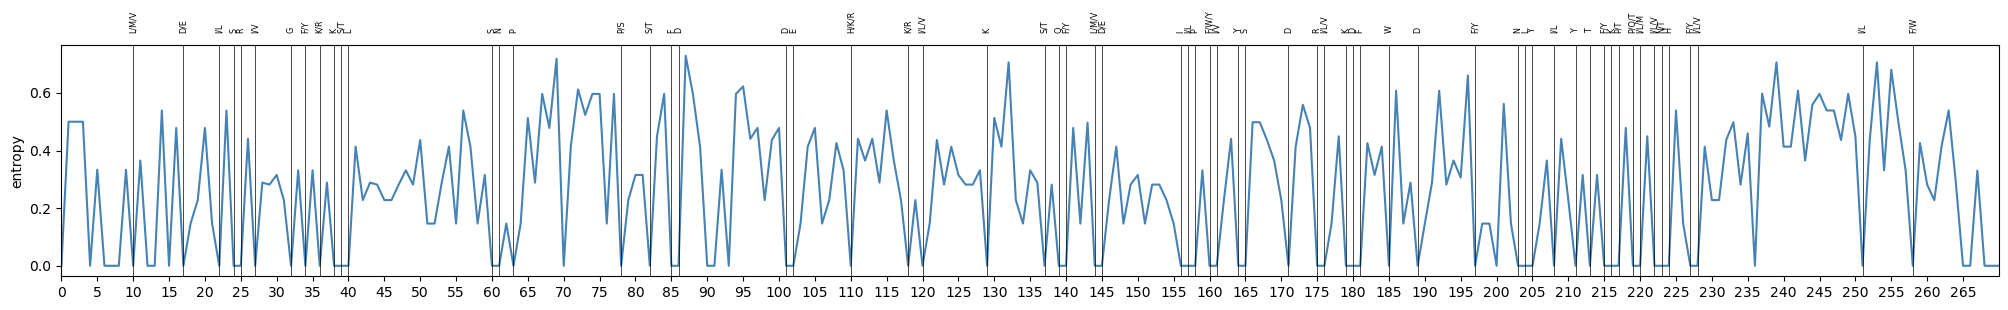

In [ ]:
MAX_ENTROPY = 0.1
msa = MSA.from_file(path='../data/genes/cluster_3.afa')

def get_entropy(msa, alphabet:dict=None, exclude_gaps:bool=False):

    alphabet_size = 20 if (alphabet is None) else len(np.unique(list(alphabet.values())))

    entropy = list()
    for col in msa.to_array(alphabet=alphabet).T:
        if (exclude_gaps and ('-' in col)) or (len(col[col != MSA.gap_symbol]) == 0):
            entropy.append(np.nan)
            continue 
        _, counts = np.unique(col[col != MSA.gap_symbol], return_counts=True)
        frequencies = counts / counts.sum()
        entropy.append(sum(-(frequencies * np.log(frequencies) / np.log(alphabet_size))))
    return np.array(entropy)

fig, ax = plt.subplots(figsize=(25, 3))

# x_min, x_max = 240, 270
x_min, x_max = 0, 270
entropy = get_entropy(msa, alphabet=REDUCED_ALPHABET)
ax.plot(np.arange(len(entropy)), entropy, color='steelblue')

conserved_idxs = np.where((entropy < MAX_ENTROPY) & (~np.isnan(entropy)))[0] 
conserved_idxs = [idx for idx in conserved_idxs if (MSA.gap_symbol not in msa.to_array().T[idx])] # Remove indices that look conserved but have a gap. 
conserved_aas = [np.unique(msa.to_array().T[idx]) for idx in conserved_idxs]

for idx, aas in zip(conserved_idxs, conserved_aas):
    if (idx > x_max) or (idx < x_min):
        continue
    ax.text(idx, ax.get_ylim()[-1] + 0.05, '/'.join(aas), ha='center', fontsize='xx-small', rotation=90)
    ax.axvline(idx, color='black', lw=0.5)

ax.set_xticks(np.arange(x_min, x_max, 5))
ax.set_xlim(xmin=x_min, xmax=x_max)
ax.set_ylabel('entropy')
plt.show()

In [ ]:
ref_gene_id = 'orfm.bz_10.1_15' # One of the higher-confidence structures. 
print(f'{ref_gene_id} PHE 92:', msa.map_idx_to_msa(92 - 1, ref_gene_id))
print(f'{ref_gene_id} PHE 125:', msa.map_idx_to_msa(125 - 1, ref_gene_id)) # Highly conserved, either F or Y. 
print(f'{ref_gene_id} PHE 124:', msa.map_idx_to_msa(124 - 1, ref_gene_id)) # Highly conserved, either F or Y. 
print(f'{ref_gene_id} PHE 221:', msa.map_idx_to_msa(221 - 1, ref_gene_id)) 
print(f'{ref_gene_id} PHE 203:', msa.map_idx_to_msa(203 - 1, ref_gene_id)) 
print(f'{ref_gene_id} PHE 209:', msa.map_idx_to_msa(209 - 1, ref_gene_id)) 
print(f'{ref_gene_id} LYS 214:', msa.map_idx_to_msa(214 - 1, ref_gene_id)) 

msa.show(start=100, stop=110)
msa.map_idx_from_msa(85, ref_gene_id) # Buried. 
msa.map_idx_from_msa(205, ref_gene_id) # On the outside of complex.
msa.map_idx_from_msa(211, ref_gene_id) # Buried.
msa.map_idx_from_msa(215, ref_gene_id) # Buried.
msa.map_idx_from_msa(34, ref_gene_id) # Buried.
msa.map_idx_from_msa(175, ref_gene_id) # Buried.
msa.map_idx_from_msa(118, ref_gene_id) # Possible contact.
msa.map_idx_from_msa(179, ref_gene_id) # Outside of pore.
msa.map_idx_from_msa(140, ref_gene_id) # Outside of pore.

orfm.bz_10.1_15 PHE 92: 108
orfm.bz_10.1_15 PHE 125: 141
orfm.bz_10.1_15 PHE 124: 140
orfm.bz_10.1_15 PHE 221: 243
orfm.bz_10.1_15 PHE 203: 221
orfm.bz_10.1_15 PHE 209: 227
orfm.bz_10.1_15 LYS 214: 232
100	MDELHNDVNA	110	orfm.bz_2.1_22
100	LDELQSILNS	110	orfm.bz_8.1_215
100	MDEMQNDLDS	110	orfm.bz_1.1_155
100	HDELQRDFGS	110	orfm.bz_7.1_194
100	HDELQRDFNS	110	orfm.bz_9.1_34
100	WDEIYADLFS	110	orfm.bz_10.1_15
100	YDEIHLDLNA	110	orfm.bz_5.1_151
100	YDEIHMDLNA	110	orfm.bz_3.1_43
100	WDEMPNDINA	110	orfm.bz_0.1_191
100	WDETTNDINA	110	orfm.bz_4.1_184
100	WDEMTNDLPA	110	orfm.bz_11.1_23


123

In [ ]:
ref_gene_id = 'orfm.bz_0.1_191' # One of the higher-confidence structures. 
print(f'{ref_gene_id} PHE 105:', msa.map_idx_to_msa(105 - 1, ref_gene_id))
msa.map_idx_from_msa(85, ref_gene_id) # Buried. 

orfm.bz_0.1_191 PHE 105: 112


81

In [ ]:
# The lysine/arginine (K/R) at positions 118 and 129 are particularly interesting. 
kr118_idx = 118
k129_idx = 129
k216_idx = 216
phe85 = 85

for row in genes_df.itertuples():
    info = f'{row.genome_id}: '
    info += 'K/R118: ' + str(msa.map_idx_from_msa(kr118_idx, row.Index) + 1)
    info += '\tK129: ' + str(msa.map_idx_from_msa(k129_idx, row.Index) + 1)
    info += '\tK216: ' + str(msa.map_idx_from_msa(k216_idx, row.Index) + 1)
    print(info)

# In bz_1, K222 looks important. Also Phe96. 
# msa.map_idx_to_msa(221, 'orfm.bz_1.1_155')
# msa.map_idx_to_msa(95, 'orfm.bz_1.1_155')

bz_0: K/R118: 111	K129: 122	K216: 208
bz_1: K/R118: 102	K129: 113	K216: 199
bz_2: K/R118: 102	K129: 113	K216: 198
bz_3: K/R118: 108	K129: 119	K216: 204
bz_4: K/R118: 101	K129: 112	K216: 198
bz_5: K/R118: 103	K129: 114	K216: 199
bz_7: K/R118: 107	K129: 118	K216: 203
bz_8: K/R118: 103	K129: 114	K216: 199
bz_9: K/R118: 97	K129: 108	K216: 193
bz_10: K/R118: 102	K129: 113	K216: 198
bz_11: K/R118: 101	K129: 112	K216: 198


In [ ]:
INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'accession', 'description', 'start','stop', 'e_value', 'status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']
INTERPROSCAN_ATPASE_ACCESSIONS = ['G3DSA:3.40.50.300', 'SSF52540']

def load_atpase_annotations(path:str, gene_ids:list=None):
    df = pd.read_csv(path, sep='\t', header=None, names=INTERPROSCAN_FIELDS)
    if gene_ids is not None:
        df = df[df.gene_id.isin(gene_ids)].copy()
    df = df[df.accession.isin(INTERPROSCAN_ATPASE_ACCESSIONS)].copy() # P-loop containing nucleoside triphosphate hydrolase
    df = df.sort_values('e_value').drop_duplicates('gene_id')
    df['gene_id'] = df.gene_id.str.lower()
    print(f'load_atpase_annotations: Found {df.gene_id.nunique()} genes with ATPase annotations in {path}.')
    return df.drop(columns=['status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways', 'checksum'])

print('P-loop containing nucleoside triphosphate hydrolase domain indices:')
for row in load_atpase_annotations('../data/genes/interproscan/genes.tsv', gene_ids=genes_df.index.values).itertuples():
    start, stop = msa.map_idx_to_msa(row.start, row.gene_id), msa.map_idx_to_msa(row.stop, row.gene_id)
    print(f'{row.gene_id}\t{start}-{stop}')


P-loop containing nucleoside triphosphate hydrolase domain indices:
load_atpase_annotations: Found 5 genes with ATPase annotations in ../data/genes/interproscan/genes.tsv.
orfm.bz_10.1_15	25-190
orfm.bz_8.1_215	25-158
orfm.bz_9.1_34	24-214
orfm.bz_7.1_194	24-199
orfm.bz_1.1_155	24-200


In [ ]:
WALKER_A_PATTERN = r'[A-Z][A-Z]{4}GK[ST]' # More general version, instead of r'[GAST][A-Z]{4}GK[ST]' 
WALKER_B_PATTERN = r'[AVLIMFYWC]{3,5}D[ED]' # More general version, instead of r'[AVLIMFYWC]{4}D[ED]' 


for row in msa.to_df().itertuples():
    wa_match = re.search(WALKER_A_PATTERN, row.seq)
    wb_match = re.search(WALKER_B_PATTERN, row.seq)

    info = f'{row.Index}'
    if wa_match is not None:
        info += f' Walker-A: {wa_match.group(0)} ({wa_match.start()} - {wa_match.end()})'
    if wb_match is not None:
        info += f' Walker-B: {wb_match.group(0)} ({wb_match.start()} - {wb_match.end()})'
    print(info)

WALKER_A_COORDS = (32, 40)
WALKER_B_COORDS = (96, 103)

for gene_id in genes_df.index:
    genes_df.loc[gene_id, 'walker_a_start'] = msa.map_idx_from_msa(WALKER_A_COORDS[0], gene_id)
    genes_df.loc[gene_id, 'walker_a_stop'] = msa.map_idx_from_msa(WALKER_A_COORDS[1], gene_id)
    genes_df.loc[gene_id, 'walker_b_start'] = msa.map_idx_from_msa(WALKER_B_COORDS[0], gene_id)
    genes_df.loc[gene_id, 'walker_b_stop'] = msa.map_idx_from_msa(WALKER_B_COORDS[1], gene_id)
# Based on the sructure, residues ~100-140 are pointed towards the inside of the toroid. 
# Residues 220-250 also look like they would be in contact with whatever is moving through the toroid. 
# ATPs look like they are binding by the W-A motif, which is good. 

orfm.bz_2.1_22 Walker-B: CIYIMDE (96 - 103)
orfm.bz_8.1_215 Walker-B: IIILDE (97 - 103)
orfm.bz_1.1_155 Walker-A: GEFGRGKT (32 - 40) Walker-B: LFIMDE (97 - 103)
orfm.bz_7.1_194 Walker-A: GEYGRGKS (32 - 40)
orfm.bz_9.1_34 Walker-A: GEYGRGKT (32 - 40)
orfm.bz_10.1_15 Walker-A: GRFGKGKS (32 - 40) Walker-B: LIIWDE (97 - 103)
orfm.bz_5.1_151 Walker-A: GRYSRGKS (32 - 40) Walker-B: IIYDE (98 - 103)
orfm.bz_3.1_43 Walker-A: GRYSRGKS (32 - 40) Walker-B: IIYDE (98 - 103)
orfm.bz_0.1_191 Walker-A: GRYSRGKS (32 - 40)
orfm.bz_4.1_184 Walker-A: GRYSRGKS (32 - 40)
orfm.bz_11.1_23 Walker-A: GRYSRGKS (32 - 40) Walker-B: IVWDE (98 - 103)


In [ ]:
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'
ALPHAFOLD_SUMMARY_FILE_PATTERN = r'(.+)_summary_confidences.json'

# ranking_score: Score used to rank models, which combined ipTM, pTM, disorder penalties, and clash penalties.
# iptm: Interface predicted TM-score, which is confidence in the relative placement of different chains (proteins, DNA, ligands).
# ptm: Predicted TM-score.
# chain_ptm: pTM calculated separately for each chain.
# chain_pair_iptm: Pairwise interface confidence between every pair of chains.
# fraction_disordered: Fraction predicted to be disordered.
# has_clash: Whether severe steric clashes were detected.

alphafold_summary_df = list()
for path in glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, '*', '*')):
    match_ = re.search(ALPHAFOLD_SUMMARY_FILE_PATTERN, os.path.basename(path))
    if match_ is None:
        continue

    job_name = match_.group(1)

    row = {'job_name':job_name}
    row['n'] = int(re.search(r'(\d+)mer', job_name).group(1))
    ligands = job_name.split('-')[-1].split('_')
    row['dna'] = 'dna' in ligands
    row['mg_atp'] = ('mg' in ligands) and ('atp' in ligands)
    row['genome_id'] = get_genome_id(job_name)

    # The ordering of the output here should be the same as the ordering of the elements (proteins, ligands, etc.) in the input file. 
    # Because of how I constructed the input JSON, proteins are first n entries, followed by Mg, ATP, and DNA.
    with open(path, 'r') as f:
        summary = json.load(f)
        row.update({field:value for field, value in summary.items() if type(value) == float})
        # Get some statistics which should not include the ligands. 
        row['mean_protein_ptm'] = np.mean(summary['chain_ptm'][:row['n']])
        if row['n'] > 1:
            # Get only the protein-protein ipTM scores to make the comparison between Mg-ATP-bound complexes and complexes
            # with no ligands more valid (not affected by ipTM scores of the ligands).
            row['mean_protein_iptm'] = np.array(summary['chain_pair_iptm'])[np.triu_indices(row['n'], 1)].mean()
    alphafold_summary_df.append(row)
alphafold_summary_df = pd.DataFrame(alphafold_summary_df)

print('Mean pTM with bound Mg-ATP (protein chain only):', alphafold_summary_df[alphafold_summary_df.mg_atp].mean_protein_ptm.mean())
print('Mean ipTM with bound Mg-ATP (protein chain only):', alphafold_summary_df[alphafold_summary_df.mg_atp].mean_protein_iptm.mean())

print('Mean pTM with no bound Mg-ATP (protein chain only):', alphafold_summary_df[~alphafold_summary_df.mg_atp].mean_protein_ptm.mean())
print('Mean ipTM with no bound Mg-ATP (protein chain only):', alphafold_summary_df[~alphafold_summary_df.mg_atp].mean_protein_iptm.mean())

n = 6
filter_ = alphafold_summary_df.job_name.str.contains(f'{n}mer')

print(f'Maximum {n}-mer ipTM with bound Mg-ATP (protein chain only):', alphafold_summary_df[filter_ & alphafold_summary_df.mg_atp].mean_protein_iptm.max())
print(f'Maximum {n}-mer ipTM with no bound Mg-ATP (protein chain only):', alphafold_summary_df[filter_ & ~alphafold_summary_df.mg_atp].mean_protein_iptm.max())

print(f'\nipTMs for Mg-ATP bound {n}-mers:')
for row in alphafold_summary_df[filter_ & alphafold_summary_df.mg_atp].sort_values('mean_protein_iptm', ascending=False).itertuples():
    print(f'\t{row.genome_id} {row.mean_protein_iptm:.2f}')

print(f'\nipTMs for non-Mg-ATP bound {n}-mers:')
for row in alphafold_summary_df[filter_ & ~alphafold_summary_df.mg_atp].sort_values('mean_protein_iptm', ascending=False).itertuples():
    print(f'\t{row.genome_id} {row.mean_protein_iptm:.2f}')


alphafold_summary_df = alphafold_summary_df[alphafold_summary_df.mg_atp].copy()

Mean pTM with bound Mg-ATP (protein chain only): 0.8607677218614718
Mean ipTM with bound Mg-ATP (protein chain only): 0.44942145949288814
Mean pTM with no bound Mg-ATP (protein chain only): 0.5945894917582418
Mean ipTM with no bound Mg-ATP (protein chain only): 0.24440731863215087
Maximum 6-mer ipTM with bound Mg-ATP (protein chain only): 0.7353333333333333
Maximum 6-mer ipTM with no bound Mg-ATP (protein chain only): 0.6226666666666667

ipTMs for Mg-ATP bound 6-mers:
	bz_9 0.74
	bz_10 0.73
	bz_3 0.72
	bz_8 0.71
	bz_7 0.71
	bz_2 0.70
	bz_4 0.68
	bz_1 0.66
	bz_5 0.64
	bz_11 0.57
	bz_0 0.50

ipTMs for non-Mg-ATP bound 6-mers:
	bz_2 0.62
	bz_10 0.54
	bz_3 0.44
	bz_10 0.38
	bz_7 0.36
	bz_7 0.30
	bz_2 0.29
	bz_3 0.26
	bz_0 0.26
	bz_9 0.26
	bz_4 0.24
	bz_9 0.22
	bz_11 0.21
	bz_8 0.20
	bz_0 0.19
	bz_4 0.17
	bz_5 0.16
	bz_8 0.16
	bz_1 0.15
	bz_1 0.13
	bz_11 0.13
	bz_5 0.10


In [ ]:
chimerx_commands = ['color gray']
chimerx_commands += ['sel :lys; color sel blue']
chimerx_commands += ['sel :arg; color sel red']
chimerx_commands += ['sel :tyr; color sel green']
chimerx_commands += ['sel :trp; color sel yellow']
chimerx_commands += ['sel :phe; color sel orange']

print('; '.join(chimerx_commands))

idxs = [139]
chains = 'FC'
atom = 'NZ'
chimerx_commands = list()
for idx in idxs:
    chimerx_commands += [f'select /{chains[0]}:{idx}@{atom} /{chains[1]}:{idx}@{atom}; distance sel']
chimerx_commands += ['color white pseudobonds; color white label']
print('; '.join(chimerx_commands))
# select /B:224@NZ /E:224@NZ
# distance sel 

# color white pseudobonds 
# color white label

# Oddly, the residues which are conserved do not appear to be the ones lining the channel (based on examination of the structures). 
# It seems possible that the structures are off, or possibly adopt different conformations. Might be worth folding with dsDNA and ssDNA and then look at 
# which residues are closest to the nucleic acid through the pore. 

# Some of the pentameric configurations (e.g. bz_3 bound to Mg and ATP) have a pore size that seems too small to be biologically-relevant
# (like 6 angstroms). This would be on the small side, even if the substrate were ssDNA. 

color gray; sel :lys; color sel blue; sel :arg; color sel red; sel :tyr; color sel green; sel :trp; color sel yellow; sel :phe; color sel orange
select /F:139@NZ /C:139@NZ; distance sel; color white pseudobonds; color white label


In [ ]:
genes_df[genes_df.genome_id == 'bz_10'].seq.iloc[0]

'MDNNIIDILRIILSRNVIMIGGRFGKGKSLSMTALTFFDIVLNNRFNILSNMPFNFPLFENINITPLTNTHQFDRIPNGTLIIWDEIYADLFSRSSGSVRNKYITIFSRDIRKIKGKIIGSVQFFDMLEKNMGLILEVIIIPEYVNIYSKITTEDMKKRIENKDFIIKWNIIDKLTNSEYELTLNLYDFIFMYDTNFKPFTLFVNHTEFVEKVKPSQIDSFRHQEEEELKMRIEHFNDNVFNTE'

In [ ]:
# This DataFrame contains the numbers of the pore residues, obtained by manual inspection of the AlphaFold structures. 
chimerx_df = pd.read_csv('../data/genes/cluster_3_chimerx.csv')
chimerx_df['complex_id'] = chimerx_df.apply(lambda row : f'{row.genome_id}_cluster_3_{row.num_subunits}mer', axis=1)
pore_residue_nums = chimerx_df.groupby('complex_id').residue_num.apply(list).to_dict()
# file_name_pattern = r'(bz_\d+)_cluster_3_(5|6)mer-mg_atp_model.cif'



ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'
ATOMS = ['NZ', 'CA', 'CB', 'CZ']

pdb_df = list()
for (genome_id, gene_id, num_subunits), df in chimerx_df.groupby(['genome_id', 'gene_id', 'num_subunits']):
    path = os.path.join(ALPHAFOLD_OUTPUT_DIR, f'{genome_id}_cluster_3_{num_subunits}mer-mg_atp', f'{genome_id}_cluster_3_{num_subunits}mer-mg_atp_model.cif')
    pdb_file = PDBFile.from_file(path)
    pdb_df.append(pdb_file.to_df().assign(genome_id=genome_id, gene_id=gene_id, num_subunits=num_subunits))
    
pdb_df = pd.concat(pdb_df)
pdb_df['complex_id'] = pdb_df.apply(lambda row : f'{row.genome_id}_cluster_3_{row.num_subunits}mer', axis=1)

In [ ]:
pore_residue_nums['bz_1_cluster_3_6mer']

[222, 96, 130, 125, 94]

get_pore_diameters: Computing pore diameter at 6 pore-lining residue positions for bz_0_cluster_3_5mer.
get_pore_diameters: Computing pore diameter at 7 pore-lining residue positions for bz_0_cluster_3_6mer.
get_pore_diameters: Computing pore diameter at 7 pore-lining residue positions for bz_10_cluster_3_5mer.
get_pore_diameters: Computing pore diameter at 8 pore-lining residue positions for bz_10_cluster_3_6mer.
get_pore_diameters: Computing pore diameter at 7 pore-lining residue positions for bz_11_cluster_3_5mer.
get_pore_diameters: Computing pore diameter at 10 pore-lining residue positions for bz_11_cluster_3_6mer.
get_pore_diameters: Computing pore diameter at 8 pore-lining residue positions for bz_1_cluster_3_5mer.
get_pore_diameters: Computing pore diameter at 5 pore-lining residue positions for bz_1_cluster_3_6mer.
get_pore_diameters: Computing pore diameter at 8 pore-lining residue positions for bz_2_cluster_3_5mer.
get_pore_diameters: Computing pore diameter at 8 pore-linin

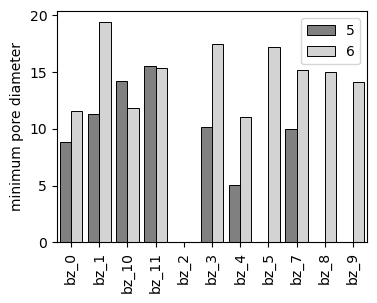

In [ ]:

def get_pore_diameters(pdb_df, pore_residue_nums:list=None):
    '''Compute the cluster_3 pore diameter at various positions along the pore, assuming symmetry (which is consistent with the
    observed structures). For each atom in each pore-lining residue, (1) compute the pairwise distance between the corresponding
    atoms in each combination of chains, and (2), take the maximum of these distances to be the diameter at that point.'''

    pore_diameter_df = list()

    assert pdb_df.chain_id.nunique() == pdb_df.num_subunits.iloc[0], f'get_pore_diameters: Expected {pdb_df.chain_id.nunique()} chains, but got {pdb_df.num_subunits.iloc[0]}.'
    assert pdb_df.genome_id.nunique() == 1, 'get_pore_diameters: Expected the input DataFrame to contain information for only one structure.'
    assert pdb_df.num_subunits.nunique() == 1,  'get_pore_diameters: Expected the input DataFrame to contain information for only one structure.'
    
    complex_id = pdb_df.complex_id.iloc[0]
    pdb_df = pdb_df[pdb_df.residue_num.isin(pore_residue_nums)].copy()
    assert len(pdb_df) > 0,  f'get_pore_diameters: pdb_df is empty. Failed on complex {complex_id}'
    
    print(f'get_pore_diameters: Computing pore diameter at {pdb_df.residue_num.nunique()} pore-lining residue positions for {complex_id}.')
    get_distance_arr = lambda df, atom: pdist(np.array(df[atom].tolist()), metric='euclidean')
    get_diameter = lambda df, atom : max(get_distance_arr(df, atom))

    for residue_num, df_ in pdb_df.groupby('residue_num'):
    # for residue_num, df_ in tqdm(pdb_df.groupby('residue_num'), desc='get_distances'):
        atoms = np.intersect1d(df_.dropna(axis=1).columns, ATOMS) # Remove atom columns which do not apply. 
        row = {atom:get_diameter(df_, atom) for atom in atoms}
        row['residue_num'] = residue_num
        row['residue'] = df_.residue.iloc[0]
        pore_diameter_df.append(row)

    return pd.DataFrame(pore_diameter_df)


def get_min_pore_diameter(complex_id, pdb_df, atoms=['CZ', 'NZ']):
    pore_diameter_df = get_pore_diameters(pdb_df, pore_residue_nums=pore_residue_nums[complex_id])
    atoms = [atom for atom in atoms if (atom in pore_diameter_df.columns)]
    diameters = [d for atom in atoms for d in pore_diameter_df[atom]] # Get diameters relative to the specified atoms. 
    diameters = [d for d in diameters if (d is not None)]
    if len(diameters) == 0:
        return None
    return min(diameters)

figure_df = pdb_df[['complex_id', 'genome_id', 'num_subunits']].drop_duplicates('complex_id').reset_index()
figure_df['min_pore_diameter'] = figure_df.complex_id.map({complex_id:get_min_pore_diameter(complex_id, df) for complex_id, df in pdb_df.groupby('complex_id')})

palette = {5:'gray', 6:'lightgray'}
fig, ax = plt.subplots(figsize=(4, 3))
sns.barplot(figure_df, x='genome_id', hue='num_subunits', y='min_pore_diameter', palette=palette, edgecolor='black', lw=0.7)
ax.get_legend().set_title('')
ax.set_xlabel('')
ax.set_ylabel('minimum pore diameter')
ax.set_xticks(ax.get_xticks(), labels=ax.get_xticklabels(), rotation=90)
plt.show()

AlphaFoldOutput.get_iptms: Could not decode 


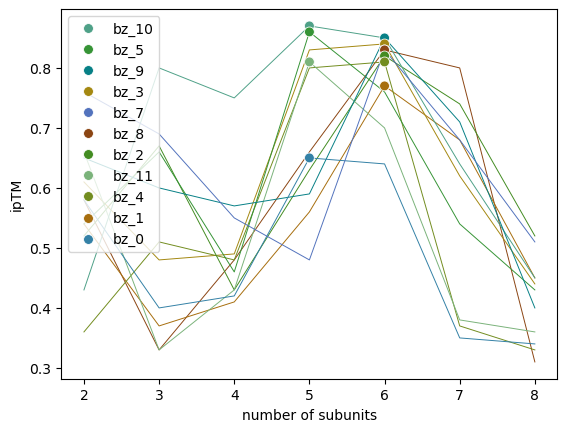

In [ ]:
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'
output_dirs = [path for path in glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, '*')) if re.search(r'bz_\d+_cluster_3_\d+mer-mg_atp', path)]

figure_df = list()
for dir_path in output_dirs:
    num_subunits = int(re.search(r'(\d+)mer', dir_path).group(1))
    if num_subunits < 2:
        continue
    output = AlphaFoldOutput(dir_path)
    iptms = list(output.get_iptms().values())
    figure_df.append({'genome_id':get_genome_id(dir_path), 'num_subunits':num_subunits, 'mean_iptm':np.mean(iptms), 'max_iptm':max(iptms)})
figure_df = pd.DataFrame(figure_df)

fig, ax = plt.subplots()
y = 'max_iptm'

cmap = LinearSegmentedColormap.from_list('palette',  ['saddlebrown', 'darkgoldenrod', 'olivedrab', 'forestgreen', 'darkseagreen', 'teal', 'steelblue', 'slateblue'])
palette = {genome_id:cmap(i / figure_df.genome_id.nunique()) for i, genome_id in enumerate(figure_df.genome_id.unique())}

sns.lineplot(figure_df, x='num_subunits', y=y, hue='genome_id', lw=0.7, palette=palette, zorder=-1,legend=False)

figure_df = figure_df.sort_values(y, ascending=False).drop_duplicates('genome_id')
sns.scatterplot(figure_df, x='num_subunits', y=y, hue='genome_id', palette=palette, s=50)

ax.set_ylabel('ipTM')
ax.set_xlabel('number of subunits')

ax.legend().set_title('')
sns.move_legend(ax, loc='upper left')

plt.show()

In [ ]:
figure_df

,genome_id,num_subunits,mean_iptm
0,bz_8,3,0.292667
1,bz_1,4,0.340333
2,bz_1,2,0.459667
3,bz_3,5,0.762000
4,bz_4,2,0.306667
...,...,...,...
72,bz_5,2,0.470000
73,bz_9,2,0.546667
74,bz_7,8,0.482632
75,bz_9,4,0.516000


In [ ]:
# Convert AlphaFold structures to PDB for pore analysis using MOLE. 

file_name_pattern = r'(bz_\d+)_cluster_3_(5|6)mer-mg_atp_model.cif'
ALPHAFOLD_OUTPUT_DIR = '../data/genes/alphafold/af_output/'

for path in glob.glob(os.path.join(ALPHAFOLD_OUTPUT_DIR, '*', '*')):
    if re.search(file_name_pattern, path) is None:
        continue

    pdb_file = PDBFile.from_file(path)
    output_file_name = os.path.basename(path).replace('.cif', '.pdb')
    output_path = os.path.join(os.path.dirname(path), output_file_name)
    if not os.path.exists(output_path):
        pdb_file.write(output_path)


In [ ]:
# # (1) HK97 phage packaging terminase (TerL) is a pentamer, see https://pmc.ncbi.nlm.nih.gov/articles/PMC10370121/, https://academic.oup.com/nar/article/50/15/8719/6659863 (TERL_BPHK7)
# # (2) Phi29 phage packaging ATPase (gp16) is also a pentamer, see https://www.nature.com/articles/s41467-019-10272-3, https://pmc.ncbi.nlm.nih.gov/articles/PMC8104870/ (PKG16_BPPH2)
# # (3) P74-26 phage terminase (TerL) is a pentamer, see https://pmc.ncbi.nlm.nih.gov/articles/PMC4517215/ (A7XXR1_BP742)
# # (4) Papillomavirus E1 helicase, involved in replication, is a hexamer, see https://pmc.ncbi.nlm.nih.gov/articles/PMC109901/ (VE1_HPV11). It binds to ssDNA, not dsDNA.

# # Based on Thomsen et. al. 2008, it seems as though many RecA-like ATPase motors are hexamers. 
# # There is potentially bias in AlphaFold structure prediction considering the abundance of hexameric ATPase assemblies. 
# # The cluster_3 protein is clearly not a terminase, and seems to most closely correspond to pI phage assembly protein (Zot-like), and the pI quaternary structure has not been solved.

# seqs = dict()
# seqs['VE1_HPV11'] = 'MADDSGTENEGSGCTGWFMVEAIVEHTTGTQISEDEEEEVEDSGYDMVDFIDDRHITQNSVEAQALFNRQEADAHYATVQDLKRKYLGSPYVSPISNVANAVESEISPRLDAIKLTTQPKKVKRRLFETRELTDSGYGYSEVEAATQVEKHGDPENGGDGQERDTGRDIEGEGVEHREAEAVDDSTREHADTSGILELLKCKDIRSTLHGKFKDCFGLSFVDLIRPFKSDRTTCADWVVAGFGIHHSIADAFQKLIEPLSLYAHIQWLTNAWGMVLLVLIRFKVNKSRCTVARTLGTLLNIPENHMLIEPPKIQSGVRALYWFRTGISNASTVIGEAPEWITRQTVIEHSLADSQFKLTEMVQWAYDNDICEESEIAFEYAQRGDFDSNARAFLNSNMQAKYVKDCAIMCRHYKHAEMKKMSIKQWIKYRGTKVDSVGNWKPIVQFLRHQNIEFIPFLSKLKLWLHGTPKKNCIAIVGPPDTGKSCFCMSLIKFLGGTVISYVNSCSHFWLQPLTDAKVALLDDATQPCWTYMDTYMRNLLDGNPMSIDRKHRALTLIKCPPLLVTSNIDISKEEKYKYLHSRVTTFTFPNPFPFDRNGNAVYELSDANWKCFFERLSSSLDIEDSEDEEDGSNSQAFRCVPGSVVRTL'
# seqs['PKG16_BPPH2'] = 'MDKSLFYNPQKMLSYDRILNFVIGARGIGKSYAMKVYPINRFIKYGEQFIYVRRYKPELAKVSNYFNDVAQEFPDHELVVKGRRFYIDGKLAGWAIPLSVWQSEKSNAYPNVSTIVFDEFIREKDNSNYIPNEVSALLNLMDTVFRNRERVRCICLSNAVSVVNPYFLFFNLVPDVNKRFNVYDDALIEIPDSLDFSSERRKTRFGRLIDGTEYGEMSLDNQFIGDSQVFIEKRSKDSKFVFSIVYNGFTLGVWVDVNQGLMYIDTAHDPSTKNVYTLTTDDLNENMMLITNYKNNYHLRKLASAFMNGYLRFDNQVIRNIAYELFRKMRIQ'
# seqs['TERL_BPHK7'] = 'MTRGERVIAFIERFCIVPEGKLIGQPMRLDPFQKDFILAVYDNPAGTDMAILSIARKNGKTGLIAGILLAHLVGPEAVQNTQIVSGALSREQAAIVFNLAVKMVNLNPKLQEIVHITPSGKKLIGLPCNVEYKALSAEGKTTHGLSPILAILDETGQVRGPQDDFIDAITTAQGAHENPLLIVISTQAANDADLLSIWIDDAVKSKDPHIVCHVYEAPKDADISKRESWLAANPALGTFRSEKDMARQAEKAGRMPSFENTFRNLNLNQRVSTVSPFISRSVWELCGEMPINTPRKWYAGLDLSARNDLTALVIAGEADDGVWDVFPFFWTPQKTLEERTKTDRAPYDVWVREGLLRTTPGASVDYSFVVADIAEIIGDFDLTSMAFDRWRIDQFRKDADAIGLSLPLVEFGQGFKDMGPAVDTLESLMLNGRVRHGMHPVLTMCAVNAVVVKDAAGNRKLDKSKATGRIDGMVAMTMSVGAANGEVTEQGGDFDDFIFRPLSM'
# seqs['A7XXR1_BP742'] = 'MKRLRPSDKFFELLGYKPHHVQLAIHRSTAKRRVACLGRQSGKSEAASVEAVFELFARPGSQGWIIAPTYDQAEIIFGRVVEKVERLAEVFPATEVQLQRRRLRLLVHHYDRPVNAPGAKRVATSEFRGKSADRPDNLRGATLDFVILDEAAMIPFSVWSEAIEPTLSVRDGWALIISTPKGLNWFYEFFLMGWRGGLKEGIPNSGINQTHPDFESFHAASWDVWPERREWYMERRLYIPDLEFRQEYGAEFVSHSNSVFSGLDMLILLPYERRGTRLVVEDYRPDHIYCIGADFGKNQDYSVFSVLDLDTGAIVCLERMNGATWSDQVARLKALSEDYGHAYVVADTWGVGDAIAEELDAQGINYTPLPVKSSSVKEQLISNLALLMEKGQVAVPNDKTILDELRNFRYYRTASGNQVMRAYGRGHDDIVMSLALAYSQYEGKDGYKFELAEERPSKLKHEESVMSLVEDDFTDLELANRAFSA'
# seqs['VE1_BPV1'] = 'MANDKGSNWDSGLGCSYLLTEAECESDKENEEPGAGVELSVESDRYDSQDEDFVDNASVFQGNHLEVFQALEKKAGEEQILNLKRKVLGSSQNSSGSEASETPVKRRKSGAKRRLFAENEANRVLTPLQVQGEGEGRQELNEEQAISHLHLQLVKSKNATVFKLGLFKSLFLCSFHDITRLFKNDKTTNQQWVLAVFGLAEVFFEASFELLKKQCSFLQMQKRSHEGGTCAVYLICFNTAKSRETVRNLMANTLNVREECLMLQPAKIRGLSAALFWFKSSLSPATLKHGALPEWIRAQTTLNESLQTEKFDFGTMVQWAYDHKYAEESKIAYEYALAAGSDSNARAFLATNSQAKHVKDCATMVRHYLRAETQALSMPAYIKARCKLATGEGSWKSILTFFNYQNIELITFINALKLWLKGIPKKNCLAFIGPPNTGKSMLCNSLIHFLGGSVLSFANHKSHFWLASLADTRAALVDDATHACWRYFDTYLRNALDGYPVSIDRKHKAAVQIKAPPLLVTSNIDVQAEDRYLYLHSRVQTFRFEQPCTDESGEQPFNITDADWKSFFVRLWGRLDLIDEEEDSEEDGDSMRTFTCSARNTNAVD'
# seqs = {gene_id.lower():seq for gene_id, seq in seqs.items()}

# terl_bphk7_dna_binding_idxs = [89, 120, 121] # Putative, not confirmed. "The corresponding residues, R101 and K56 of P74-26 and phi29, respectively, have been shown to contribute to DNA binding."
# a7xxr1_bp742_dna_binding_idxs = [99, 100, 101, 103, 127, 129] # Confirmed?


# atpase_df = pd.DataFrame(index=list(seqs.keys()))
# atpase_df['seq'] = atpase_df.index.map(seqs) # FASTAFile.from_df(atpase_df).write('../data/genes/atpase.faa')
# atpase_df = atpase_df.merge(load_atpase_annotations('../data/genes/interproscan/atpase.tsv').set_index('gene_id'), left_index=True, right_index=True, how='left')
# atpase_df['atpase_domain'] = [row.seq[row.start:row.stop] for row in atpase_df.itertuples()] # Extract the ATPase domain. 

# ATPASE_DOMAIN_COORDS = (24, 215) # Relative to the Betazoid cluster_3 MSA.

# for row in genes_df.itertuples():
#     start, stop = msa.map_idx_from_msa(ATPASE_DOMAIN_COORDS[0], row.Index), msa.map_idx_from_msa(ATPASE_DOMAIN_COORDS[1], row.Index)
#     atpase_df.loc[row.Index, 'seq'] = row.seq 
#     atpase_df.loc[row.Index, 'start'] = start 
#     atpase_df.loc[row.Index, 'stop'] = stop
#     atpase_df.loc[row.Index, 'atpase_domain'] = row.seq[start:stop]

# for row in atpase_df[~atpase_df.index.str.startswith('orfm')].itertuples():
#     print(row.Index, f'ATPase domain coordinates: {int(row.start)}-{int(row.stop)}')

# FASTAFile.from_df(atpase_df).write('../data/genes/atpase.faa')
# # FASTAFile.from_df(atpase_df.drop(columns='seq').rename(columns={'atpase_domain':'seq'})).write('../data/genes/atpase_domains.faa')
# # First attempt was a sequence-based alignment, which failed, even after trimming the sequences to the ATPase domain. 


In [ ]:
FOLDSEEK_INPUT_DIR = '../data/genes/foldseek/structures/cluster_3'
FOLDSEEK_TMP_DIR = '../data/tmp'
FOLDSEEK_QUERY_DATABASE_PATH = '../data/genes/foldseek/db/cluster_3/cluster_3'
FOLDSEEK_OUTPUT_DATABASE_PATH = '../data/genes/foldseek/db/cluster_3.out/cluster_3.out'
FOLDSEEK_FIELDS = '"query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"'
FOLDSEEK_OUTPUT_PATH = '../data/genes/foldseek/cluster_3.tsv'

COLABFOLD_DIR = '../data/genes/colabfold'
COLABFOLD_FILE_NAME_PATTERN = '*_relaxed_rank_001_alphafold2_ptm_model*'

print(f'foldseek createdb {FOLDSEEK_INPUT_DIR} {FOLDSEEK_QUERY_DATABASE_PATH}')
print(f'foldseek search {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_OUTPUT_DATABASE_PATH} {FOLDSEEK_TMP_DIR} --alignment-type 1 -a')
print(f'foldseek convertalis {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_OUTPUT_DATABASE_PATH} {FOLDSEEK_OUTPUT_PATH} --format-output {FOLDSEEK_FIELDS}')

foldseek_align_df = pd.read_csv(FOLDSEEK_OUTPUT_PATH, sep='\t', names=FOLDSEEK_FIELDS.replace('"', '').split(','))

# foldseek_align_df = foldseek_align_df.pivot(index='query', columns='target', values='alntmscore')

foldseek createdb ../data/genes/foldseek/structures/cluster_3 ../data/genes/foldseek/db/cluster_3/cluster_3
foldseek search ../data/genes/foldseek/db/cluster_3/cluster_3 ../data/genes/foldseek/db/cluster_3/cluster_3 ../data/genes/foldseek/db/cluster_3.out/cluster_3.out ../data/tmp --alignment-type 1 -a
foldseek convertalis ../data/genes/foldseek/db/cluster_3/cluster_3 ../data/genes/foldseek/db/cluster_3/cluster_3 ../data/genes/foldseek/db/cluster_3.out/cluster_3.out ../data/genes/foldseek/cluster_3.tsv --format-output "query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"


In [ ]:
FOLDSEEK_FIELDS = ['query', 'target', 'evalue', 'gapopen', 'pident', 'fident', 'nident', 'qstart', 'qend', 'qlen', 'tstart', 'tend', 'tlen', 'alnlen', 'bits', 'cigar', 'qseq', 'tseq', 'qheader', 'theader', 'qaln', 'taln', 'mismatch', 'qcov', 'tcov','taxid', 'taxname', 'taxlineage', 'lddt', 'lddtfull', 'qtmscore', 'ttmscore', 'alntmscore', 'rmsd', 'prob']
FOLDSEEK_TARGET_DATABASE_PATTERN = r'alphafold_swissprot|alphafold_uniprot|pdb|bfvd'

paths = {re.search(FOLDSEEK_TARGET_DATABASE_PATTERN, path).group(0):path for path in glob.glob('../data/genes/foldseek/*') if re.search(FOLDSEEK_TARGET_DATABASE_PATTERN, path)}
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(target_database=target_database) for target_database, path in paths.items()])
foldseek_search_df = foldseek_search_df[foldseek_search_df['query'].isin(genes_df.index.values)].copy()
foldseek_search_df['num_gaps'] = [max(row.qaln.count('-'), row.taln.count('-')) for row in foldseek_search_df.itertuples()]
foldseek_search_df = foldseek_search_df.drop(columns=['cigar', 'qtmscore', 'ttmscore', 'qheader', 'rmsd', 'fident', 'pident', 'nident', 'taxid'], errors='ignore')

for gene_id, df in foldseek_search_df.groupby('query'):
    num_hits_by_target_database = df.value_counts('target_database')
    num_hits_by_target_database = [f'{target_database} ({n})' for target_database, n in zip(num_hits_by_target_database.index, num_hits_by_target_database.values)]
    num_hits_by_target_database = ' '.join(num_hits_by_target_database)
    print(f'Number of Foldseek hits for {gene_id}:', len(df), f'\t{num_hits_by_target_database}')

Number of Foldseek hits for orfm.bz_0.1_191: 3994 	alphafold_uniprot (1218) alphafold_swissprot (949) pdb (921) bfvd (906)
Number of Foldseek hits for orfm.bz_1.1_155: 4030 	alphafold_uniprot (1217) alphafold_swissprot (975) pdb (956) bfvd (882)
Number of Foldseek hits for orfm.bz_10.1_15: 4038 	alphafold_uniprot (1218) alphafold_swissprot (954) pdb (951) bfvd (915)
Number of Foldseek hits for orfm.bz_11.1_23: 4052 	alphafold_uniprot (1217) alphafold_swissprot (982) pdb (933) bfvd (920)
Number of Foldseek hits for orfm.bz_2.1_22: 4059 	alphafold_uniprot (1215) alphafold_swissprot (992) pdb (953) bfvd (899)
Number of Foldseek hits for orfm.bz_3.1_43: 4078 	alphafold_uniprot (1215) alphafold_swissprot (987) pdb (956) bfvd (920)
Number of Foldseek hits for orfm.bz_4.1_184: 3948 	alphafold_uniprot (1215) alphafold_swissprot (959) pdb (908) bfvd (866)
Number of Foldseek hits for orfm.bz_5.1_151: 4057 	alphafold_uniprot (1217) alphafold_swissprot (990) pdb (953) bfvd (897)
Number of Foldseek

In [ ]:
filters = dict()
# filters['large_e_value'] = foldseek_search_df.evalue > 0.5
filters['too_many_gaps'] = (foldseek_search_df.gapopen > 15) | (foldseek_search_df.num_gaps > 50)
# filters['low_tm_score'] = foldseek_search_df.alntmscore < 0.6
# filters['short_target'] = (foldseek_search_df.tlen < 50) | (foldseek_search_df.num_gaps > 50)

foldseek_search_df = apply_filters(filters, foldseek_search_df).sort_values('bits')

apply_filters: 40321 entries removed by too_many_gaps.


In [ ]:
foldseek_search_categories = dict()
foldseek_search_categories['RecA'] = foldseek_search_df.theader.str.contains('RecA|recA')
foldseek_search_categories['Zot'] = foldseek_search_df.theader.str.contains('Zot|Zona|occludens')
foldseek_search_categories['ATPase'] = foldseek_search_df.theader.str.contains('ATP|AAA')
foldseek_search_categories['uncharacterized'] = foldseek_search_df.theader.str.contains('uncharacterized', case=False) 
foldseek_search_categories['PhoH'] = foldseek_search_df.theader.str.contains('PhoH') 
foldseek_search_categories['terminase'] = foldseek_search_df.theader.str.contains('terminase') 
foldseek_search_categories['helicase'] = foldseek_search_df.theader.str.contains('helicase', case=False) 
foldseek_search_categories['recombinase'] = foldseek_search_df.theader.str.contains('recombinase', case=False) 
foldseek_search_categories['transposase'] = foldseek_search_df.theader.str.contains('transposase', case=False) 
foldseek_search_categories['RFC'] = foldseek_search_df.theader.str.contains('Replication factor C|Clamp Loader|RFC') 
foldseek_search_categories['MutS'] = foldseek_search_df.theader.str.contains('MutS|mismatch repair', case=False) 
foldseek_search_categories['thymidine kinase'] = foldseek_search_df.theader.str.contains('thymidine kinase', case=False) 
foldseek_search_categories['pilus assembly'] = foldseek_search_df.theader.str.contains('pilus', case=False) # No hits survive the filter. 
# items() output is [(key, value), (key, value), ...]. Then zip() takes the corresponding elements of each tuple, so end up with [(key, key, ...), (value, value, ..)]
foldseek_search_categories = list(zip(*list(foldseek_search_categories.items())))
foldseek_search_df['category'] = np.select(condlist=foldseek_search_categories[-1], choicelist=foldseek_search_categories[0], default='none')


In [ ]:
# RecA forms a filament, not a pore, so a RecA-like mechanism is unlikely. 

foldseek_search_df[foldseek_search_df.category == 'helicase'][['theader', 'tcov', 'qcov', 'alntmscore']].sort_values('alntmscore')
foldseek_search_df[['theader', 'tcov', 'qcov', 'alntmscore']].sort_values('alntmscore').iloc[-10:]

,theader,tcov,qcov,alntmscore
153292,AF-X1CVG9-F1-model_v6 Zona occludens toxin N-t...,0.956,0.553,0.9047
195954,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.955,0.875,0.9048
117506,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.955,0.839,0.9062
135183,A0A6J5KM92,0.362,0.146,0.9067
55250,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.961,0.849,0.9069
56466,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.966,0.815,0.9082
77579,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.961,0.801,0.9142
151,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.955,0.854,0.9181
135155,A0A8S5VDT6,0.376,0.146,0.9209
153182,AF-A0A135VTB6-F1-model_v6 Zona occludens toxin...,0.961,0.848,0.9217


In [ ]:
genes_df

,nt_seq,description,seq,frame,gene_number,start,stop,strand,partial,has_start_codon,...,prodigal_start_idx,genome_size,seq_untrimmed,nt_seq_untrimmed,num_residues_trimmed,cluster_id,walker_a_start,walker_a_stop,walker_b_start,walker_b_stop
gene_id,,,,,,,,,,,,,,,,,,,,,
orfm.bz_0.1_191,TTGCGAACTTTGCGTCTTTGCGGTGAAAACGTGCAAGAAAAGGAAA...,NaN,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,2,191,1800,2588,-,False,True,...,2.0,19040,KSLRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLT...,AAATCTTTGCGAACTTTGCGTCTTTGCGGTGAAAACGTGCAAGAAA...,2,3.0,29.0,37.0,88.0,95.0
orfm.bz_1.1_155,ATGACTTCAATATCTGAAATATTTGATATTATTTTTTCAAGGAAAA...,NaN,MTSISEIFDIIFSRKIIIFGGEFGRGKTLCMTAYAYFASILNNKNN...,1,155,2418,3179,-,False,True,...,-1.0,17509,KIKIMTSISEIFDIIFSRKIIIFGGEFGRGKTLCMTAYAYFASILN...,AAAATAAAAATTATGACTTCAATATCTGAAATATTTGATATTATTT...,4,3.0,20.0,28.0,79.0,86.0
orfm.bz_2.1_22,ATGAATAAACTTGATTTGCTTCATTCTTTATTTAGTCGCCACATTA...,NaN,MNKLDLLHSLFSRHIILWGGEYGRSKSLSLCAFTFLECLLDNKKLI...,6,22,1172,1982,-,False,True,...,-1.0,15579,NINMNKLDLLHSLFSRHIILWGGEYGRSKSLSLCAFTFLECLLDNK...,AATATAAATATGAATAAACTTGATTTGCTTCATTCTTTATTTAGTC...,3,3.0,19.0,27.0,79.0,86.0
orfm.bz_3.1_43,ATGCAAACAAATAGGAAAATAATGAATAATAAAGAAATAATTGAAT...,NaN,MQTNRKIMNNKEIIELILSRYVVIIGGRYSRGKSLSLTALNFFDMI...,5,43,2530,3331,-,False,True,...,6.0,17033,YIPKINKFSMQTNRKIMNNKEIIELILSRYVVIIGGRYSRGKSLSL...,TACATACCAAAAATTAATAAATTTTCAATGCAAACAAATAGGAAAA...,9,3.0,26.0,34.0,85.0,92.0
orfm.bz_4.1_184,TTGAAAGAAATTGATATAATACAATTGATATTAAGTAGATATGTGG...,NaN,LKEIDIIQLILSRYVVFVGGRYSRGKSLIITFLTLMDLILNNRNSI...,1,184,4053,4817,-,False,True,...,-1.0,20548,IGCILKEIDIIQLILSRYVVFVGGRYSRGKSLIITFLTLMDLILNN...,ATAGGGTGTATCTTGAAAGAAATTGATATAATACAATTGATATTAA...,4,3.0,19.0,27.0,78.0,85.0
orfm.bz_5.1_151,GTGAAAAAAATGATATTATCCAATATAGAAATATTAAAACTTATAC...,NaN,VKKMILSNIEILKLILSRYVVIFGGRYSRGKSLSLTALNFFDIMLN...,1,151,1325,2095,-,False,True,...,2.0,16014,GKVKKMILSNIEILKLILSRYVVIFGGRYSRGKSLSLTALNFFDIM...,GGAAAGGTGAAAAAAATGATATTATCCAATATAGAAATATTAAAAC...,2,3.0,24.0,32.0,80.0,87.0
orfm.bz_7.1_194,TTGTTTGTGTGGAATATGAATACAAAAGAAATACTTGATATTATTT...,NaN,LFVWNMNTKEILDIISSRKVILIAGEYGRGKSLSGTALIFMLCVLS...,1,194,1204,1989,-,False,True,...,4.0,16817,WLFVWNMNTKEILDIISSRKVILIAGEYGRGKSLSGTALIFMLCVL...,TGGTTGTTTGTGTGGAATATGAATACAAAAGAAATACTTGATATTA...,1,3.0,24.0,32.0,84.0,91.0
orfm.bz_8.1_215,ATGAATAATTTAGATAAACTTAATATTATTTTCAGTAGATGGATAA...,NaN,MNNLDKLNIIFSRWIIIFGGEFGRCKSLSITALTFLELLYTKKSKI...,3,215,1806,2576,-,False,True,...,-1.0,21195,IKIIMNNLDKLNIIFSRWIIIFGGEFGRCKSLSITALTFLELLYTK...,ATCAAGATAATTATGAATAATTTAGATAAACTTAATATTATTTTCA...,4,3.0,19.0,27.0,80.0,87.0
orfm.bz_9.1_34,ATGAATAATCAAGAAATATTTGATTTACTGGAATCAAGAAAGGTAA...,NaN,MNNQEIFDLLESRKVIVIAGEYGRGKTLSGIALTWYLTILYQHFNV...,4,34,2676,3426,-,False,True,...,-1.0,18925,KIMNNQEIFDLLESRKVIVIAGEYGRGKTLSGIALTWYLTILYQHF...,AAAATCATGAATAATCAAGAAATATTTGATTTACTGGAATCAAGAA...,2,3.0,19.0,27.0,74.0,81.0


In [15]:
# Based on preliminary attempts with AlphaFold and the Foldseek hits, it seems likely that cluster_1 forms a homo-oligomer (or possibly with cluster_2, but
# one protein seems more likely). Still would like to try different configurations to get a rigorous assessment of the best configuration. 
ALPHAFOLD_INPUT_DIR = '../data/genes/alphafold/af_input/cluster_3' # Directory name to match what is required on biotite.
os.makedirs(ALPHAFOLD_INPUT_DIR, exist_ok=True)


file_names = list()
for row in genes_df.itertuples():
    for n in range(1, 9):
        file = AlphaFoldInputFile(f'{row.genome_id}_cluster_3_{n}mer')
        file.add_seq(row.seq, n=n)
        file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{file.name}.json'))
        file_names += [f'{file.name}.json']

        file = AlphaFoldInputFile(f'{row.genome_id}_cluster_3_{n}mer-mg_atp')
        file.add_seq(row.seq, n=n)
        file.add_mg(n=n)
        file.add_atp(n=n)
        file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{file.name}.json'))
        file_names += [f'{file.name}.json']

        file = AlphaFoldInputFile(f'{row.genome_id}_cluster_3_{n}mer-mg_adp')
        file.add_seq(row.seq, n=n)
        file.add_mg(n=n)
        file.add_adp(n=n)
        file.write(os.path.join(ALPHAFOLD_INPUT_DIR, f'{file.name}.json'))
        file_names += [f'{file.name}.json']

print('sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_3/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output"')

# https://app.gitbook.com/o/-LzcB3BNVSNh_20MBLKi/s/-M-S5z_vnCqDzDHcfsmi/protein-folding
# run_alphafold3 --json_path=/root/af_input/af_input.json --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output


sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_3/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output"


In [ ]:
# Is there a conserved in-frame start codon?
for row in genes_df.itertuples():
    codons = np.array([row.nt_seq[i:i+3] for i in range(0, len(row.nt_seq), 3)])
    start_codon_idxs = np.where(np.isin(codons, ['ATG', 'GTG']))[0]
    print(f'{row.Index} start codon locations:', ' '.join(start_codon_idxs.astype(str)), '-', len(row.seq))

orfm.bz_0.1_191 start codon locations: 10 45 47 53 59 72 84 95 229 249 255 256 - 259
orfm.bz_1.1_155 start codon locations: 0 30 83 86 96 104 137 157 192 213 - 248
orfm.bz_2.1_22 start codon locations: 0 49 83 96 134 191 199 222 242 - 266
orfm.bz_3.1_43 start codon locations: 0 7 44 52 56 94 197 - 257
orfm.bz_4.1_184 start codon locations: 14 35 49 126 165 191 245 246 - 249
orfm.bz_5.1_151 start codon locations: 0 3 43 54 167 192 202 - 253
orfm.bz_7.1_194 start codon locations: 2 5 40 129 171 253 - 259
orfm.bz_8.1_215 start codon locations: 0 49 55 132 135 138 192 - 251
orfm.bz_9.1_34 start codon locations: 0 51 103 119 176 186 228 - 247
orfm.bz_10.1_15 start codon locations: 0 18 31 51 126 131 155 191 230 239 - 244
orfm.bz_11.1_23 start codon locations: 0 3 35 49 61 85 130 188 246 - 249


In [ ]:
# def dssp_add_pdb_header(path, output_dir='../data/genes/dssp/cluster_1/'):
#     # '''The ColabFold output PDB files contain ATOM entries for hydrogens, which is not compatible with the DSSP parser.'''
#     with open(path, 'r') as f:
#         lines = f.readlines()

#     # has_hydrogen = lambda line : line.strip().split()[-1] == 'H'
#     # lines = [line for line in lines if not has_hydrogen(line)]
#     lines = ['HEADER\tPROTEIN']
#     output_path = os.path.join(output_dir, os.path.basename(path))
#     with open(output_path, 'w') as f:
#         f.write('\n'.join(lines))
#     return output_path
    

In [ ]:
# def get_alphafold_input(gene_id, seq, n:int=1, dna:bool=False, atp:bool=False, mg:bool=False):
#     '''AlphaFold3 takes a JSON-style input, described here: https://github.com/google-deepmind/alphafold3/blob/main/docs/input.md'''
#     name = f'{get_genome_id(gene_id)}_cluster_1_{n}mer'
#     ligands = list()

#     input = dict()
#     input['modelSeeds'] = [1] # Maybe worth using multiple seeds?
#     input['dialect'] = 'alphafoldserver' # Biotite guidelines say to use 'alphafold3' here, but this produces an error.
#     input['version'] = 1
#     input['sequences'] = list()
#     input['sequences'].append({'protein':{'sequence':seq, 'id':[f'P{i}' for i in range(n)]}})
#     if mg:
#         ligands += ['mg']
#         input['sequences'].append({'ligand':{'ccdCodes':['MG'], 'id':[f'M{i}' for i in range(n)]}})
#     if atp:
#         ligands += ['atp']
#         input['sequences'].append({'ligand':{'id':[f'A{i}' for i in range(n)], 'ccdCodes':['ATP']}})
#     if dna:
#         ligands += ['dna']
#         input['sequences'].append({'dna':{'sequence':ALPHAFOLD_DNA_SEQ, 'id':['D1']}})
#         input['sequences'].append({'dna':{'sequence':reverse_complement(ALPHAFOLD_DNA_SEQ), 'id':['D2']}})
#     input['name'] = name + '-' + '_'.join(ligands) if (len(ligands) > 0) else name
#     return input 


In [ ]:
# # Want to look for conserved arginine and/or lysine residues which could be involved in DNA binding (excluding the conserved R/K in the
# # Walker-A motif, which is for ATP binding).

# is_dna_binding = lambda aas : np.all(np.isin(aas, ['R', 'K']))

# dna_binding_idxs = list()
# for idx, aas in zip(conserved_idxs, conserved_aas):
#     if not is_dna_binding(aas):
#         continue
#     if np.isin(idx, np.arange(WALKER_A_COORDS[0], WALKER_A_COORDS[1] + 1)):
#         print(f'Skipping index {idx} because it is part of the Walker-A motif.')
#         continue 
#     if np.isin(idx, np.arange(WALKER_B_COORDS[0], WALKER_B_COORDS[1] + 1)):
#         print(f'Skipping index {idx} because it is part of the Walker-B motif.')
#         continue 
#     dna_binding_idxs.append(idx)

# print('Number of candidate DNA-binding residues:', len(dna_binding_idxs))



In [ ]:
# ! muscle -align ../data/genes/atpase_domains.faa -output ../data/genes/atpase_domains.afa
# atpase_domains_msa = MSA('../data/genes/atpase_domains.afa')
# print(str(atpase_domains_msa))

# CARETTA_INPUT_DIR = '../data/genes/caretta/structures/atpase_domains/'
# CARETTA_OUTPUT_DIR = '../data/genes/caretta/atpase_domains.out/'
# cmd = f'\ncaretta-cli {CARETTA_INPUT_DIR} --no-pdb --matrix --output {CARETTA_OUTPUT_DIR} --features\n'
# print(cmd)

# paths = {gene_id:f'../data/genes/alphafold/fold_{gene_id}_1mer_mg_atp/fold_{gene_id}_1mer_mg_atp_model_0.cif' for gene_id in seqs.keys()}

# pattern = r'|'.join([fr'{gene_id}_relaxed_rank_001_alphafold2_ptm_model_\d_seed_000.pdb' for gene_id in genes_df.index])
# paths.update({get_gene_id(path):path for path in glob.glob('../data/genes/colabfold/*/*pdb') if (re.search(pattern, path) is not None)})

# # For the structural alignment, want to subset the structure to match the ATPase domain. 
# for gene_id, path in paths.items():
#     if gene_id[:2] == 'or':
#         output_path = os.path.join(CARETTA_INPUT_DIR, f'{gene_id.lower()}_atpase_domain.pdb')
#         start, stop = atpase_df.loc[gene_id].start, atpase_df.loc[gene_id].stop
#         PDBFile.from_file(path).subset(output_path, start=start, stop=stop)

# # caretta -i ./structures/atpase_domains -o ./
# atpase_domain_msa = MSA(f'{CARETTA_OUTPUT_DIR}result.fasta')

In [ ]:
# FOLDSEEK_INPUT_DIR = '../data/genes/foldseek/structures/atpase_domains'
# FOLDSEEK_TMP_DIR = '../data/tmp'
# FOLDSEEK_QUERY_DATABASE_PATH = '../data/genes/foldseek/db/atpase_domains/atpase_domains'
# FOLDSEEK_OUTPUT_DATABASE_PATH = '../data/genes/foldseek/db/atpase_domains.out/atpase_domains.out'
# FOLDSEEK_FIELDS = '"query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"'
# FOLDSEEK_OUTPUT_PATH = '../data/genes/foldseek/atpase_domains.tsv'

# COLABFOLD_DIR = '../data/genes/colabfold'
# COLABFOLD_FILE_NAME_PATTERN = r'|'.join([fr'{gene_id}_relaxed_rank_001_alphafold2_ptm_model_\d_seed_000.pdb' for gene_id in genes_df.index])

# paths = {gene_id:f'../data/genes/alphafold/fold_{gene_id}_1mer_mg_atp/fold_{gene_id}_1mer_mg_atp_model_0.cif' for gene_id in seqs.keys()}
# paths.update({get_gene_id(path):path for path in glob.glob('../data/genes/colabfold/*/*pdb') if (re.search(COLABFOLD_FILE_NAME_PATTERN, path) is not None)})

# # For the structural alignment, want to subset the structure to match the ATPase domain. 
# for gene_id, path in paths.items():
#     output_path = os.path.join(FOLDSEEK_INPUT_DIR, f'{gene_id.lower()}_atpase_domain.pdb')
#     if not os.path.exists(output_path):
#         start, stop = atpase_df.loc[gene_id].start, atpase_df.loc[gene_id].stop
#         PDBFile.from_file(path).subset(output_path, start=start, stop=stop)

    
# print(f'foldseek createdb {FOLDSEEK_INPUT_DIR} {FOLDSEEK_QUERY_DATABASE_PATH}')
# print(f'foldseek search {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_OUTPUT_DATABASE_PATH} {FOLDSEEK_TMP_DIR} --alignment-type 1 -a')
# print(f'foldseek convertalis {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_QUERY_DATABASE_PATH} {FOLDSEEK_OUTPUT_DATABASE_PATH} {FOLDSEEK_OUTPUT_PATH} --format-output {FOLDSEEK_FIELDS}')

# foldseek_align_df = pd.read_csv(FOLDSEEK_OUTPUT_PATH, sep='\t', names=FOLDSEEK_FIELDS.replace('"', '').split(','))

# # foldseek_align_df = foldseek_align_df.pivot(index='query', columns='target', values='alntmscore')

In [ ]:
# Commands to run in biotite. Actually, now mkdssp can be run locally! After I installed it according to the instructions on the GitHub. 
# for file_name in os.listdir('../data/genes/dssp/structures/cluster_3/'):
#     gene_id = get_gene_id(file_name)
#     cmd = f'mkdssp /home/philippar/dssp/structures/cluster_3/{file_name} /home/philippar/dssp/{gene_id}.dssp --output-format dssp'
#     # print(cmd)


# print(f'genome ID\thelix start\thelix end\thelix length')
# for path in glob.glob('../data/genes/dssp/*dssp'):
#     if get_genome_id(path) == 'bz_2':
#         # The bz_2 cluster_3 protein has a little extra strand at the end with helix predictions, which I want to ignore. 
#         dssp = str(DSSPFile.from_file(path))[:-12] + ' ' # Add an extra character in case the helix continues to the end of the sequence.
#     else: 
#         dssp = str(DSSPFile.from_file(path)) + ' ' # Add an extra character in case the helix continues to the end of the sequence.
#     dssp = np.array(list(dssp)) # Get the C-terminus as an array. 
    
#     values = np.diff((dssp == 'H').astype(int))
#     stop_idx = np.where(values == -1)[0][-1] # Get the last "helix close" spot. 
#     start_idx = np.where(values == 1)[0][-1] # Get the last "helix open" spot. 
#     print(f'{get_genome_id(path)}\t{start_idx}\t{stop_idx}\t{stop_idx - start_idx}')

In [ ]:
# RESIDUE_CHARGES = {'A':'.', 'C':'.', 'D':'-', 'E':'-', 'F': '.', 'G':'.', 'H':'.', 'I':'.', 'K':'+', 'L':'.', 'M':'.', 'N':'.', 'P':'.', 'Q':'.', 'R':'+', 'S':'.', 'T':'.', 'V':'.', 'W':'.', 'Y':'.'}

# get_charge = lambda seq : ''.join([RESIDUE_CHARGES[aa] for aa in seq])
# get_net_charge = lambda seq : get_charge(seq).count('+') - get_charge(seq).count('-')

# for row in genes_df.itertuples():
#     charges = get_charge(row.seq[-30:])
#     print(f'{row.Index}\t', charges, f'\t({len(charges)}, {100 * charges.count('+') / len(charges):.2f}%, {get_net_charge(row.seq[-30:])})')